Cell 1 Import libraries

In [ ]:
import os
import cv2
import random
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

warnings.filterwarnings("ignore")

from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input as effnet_preprocess
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.preprocessing.image import ImageDataGenerator

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight

SEED = 42
IMG_SIZE = 224
SAMPLES_PER_CLASS = 800
BATCH_SIZE = 16

np.random.seed(SEED)
tf.random.set_seed(SEED)
random.seed(SEED)

print("Libraries loaded successfully")

Libraries loaded successfully


Cell 2 Download dataset

In [ ]:
import kagglehub

dataset_path = kagglehub.dataset_download("tawsifurrahman/covid19-radiography-database")
print("Dataset path:", dataset_path)

Dataset path: /Users/adnansadat/.cache/kagglehub/datasets/tawsifurrahman/covid19-radiography-database/versions/5


Cell 3 Set up dataset folders

In [ ]:
possible_dirs = [
    os.path.join(dataset_path, "COVID-19_Radiography_Dataset"),
    os.path.join(dataset_path, "COVID-19RadiographyDataset"),
    dataset_path
]

dataset_dir = next((d for d in possible_dirs if os.path.exists(d)), dataset_path)

class_names = ["COVID", "Normal", "Viral Pneumonia", "Lung_Opacity"]
class_dirs = {}

for cls in class_names:
    img_dir = os.path.join(dataset_dir, cls, "images")
    if os.path.exists(img_dir):
        class_dirs[cls] = img_dir

print("Image counts per class:")
for cls, path in class_dirs.items():
    count = len([f for f in os.listdir(path) if f.lower().endswith((".png", ".jpg", ".jpeg"))])
    print(f"{cls}: {count} images")

Image counts per class:
COVID: 3616 images
Normal: 10192 images
Viral Pneumonia: 1345 images
Lung_Opacity: 6012 images


Cell 4 Clean unreadable images

In [ ]:
valid_images = {cls: [] for cls in class_names}
corrupted = []

for cls, path in class_dirs.items():
    files = [f for f in os.listdir(path) if f.lower().endswith((".png", ".jpg", ".jpeg"))]
    seen = set()

    for fname in files:
        if fname in seen:
            continue
        seen.add(fname)

        fpath = os.path.join(path, fname)

        try:
            img = cv2.imread(fpath)
            if img is None:
                raise ValueError("Unreadable image")
            valid_images[cls].append(fpath)
        except:
            corrupted.append(fpath)

print("Corrupted/unreadable images removed:", len(corrupted))
for cls in class_names:
    print(f"{cls}: {len(valid_images[cls])} valid images")

Corrupted/unreadable images removed: 0
COVID: 3616 valid images
Normal: 10192 valid images
Viral Pneumonia: 1345 valid images
Lung_Opacity: 6012 valid images


Cell 5 Plot class distribution

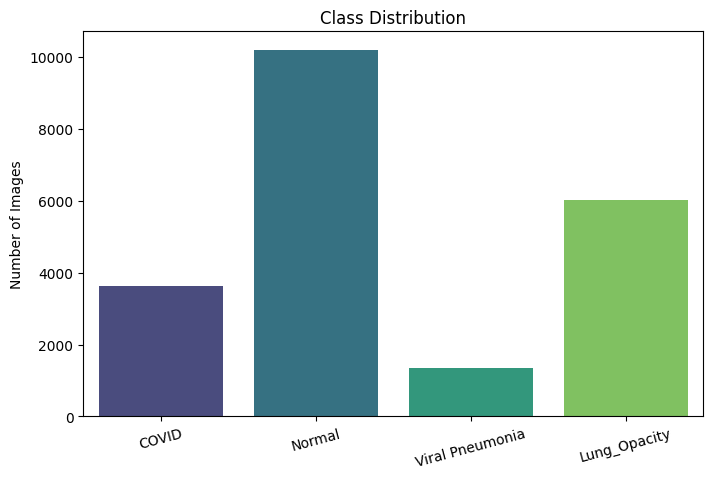

In [ ]:
plt.figure(figsize=(8, 5))
counts = [len(valid_images[c]) for c in class_names]
sns.barplot(x=class_names, y=counts, palette="viridis")
plt.title("Class Distribution")
plt.ylabel("Number of Images")
plt.xticks(rotation=15)
plt.show()

Cell 6 CLAHE preprocessing function

In [ ]:
def apply_clahe_and_resize(img_path, img_size=IMG_SIZE):
    img = cv2.imread(img_path)
    if img is None:
        raise ValueError(f"Cannot read image: {img_path}")

    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    lab = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2LAB)
    l, a, b = cv2.split(lab)

    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    l_eq = clahe.apply(l)

    enhanced = cv2.merge([l_eq, a, b])
    enhanced = cv2.cvtColor(enhanced, cv2.COLOR_LAB2RGB)
    enhanced = cv2.resize(enhanced, (img_size, img_size))

    return enhanced

Cell 7 Show original and CLAHE images

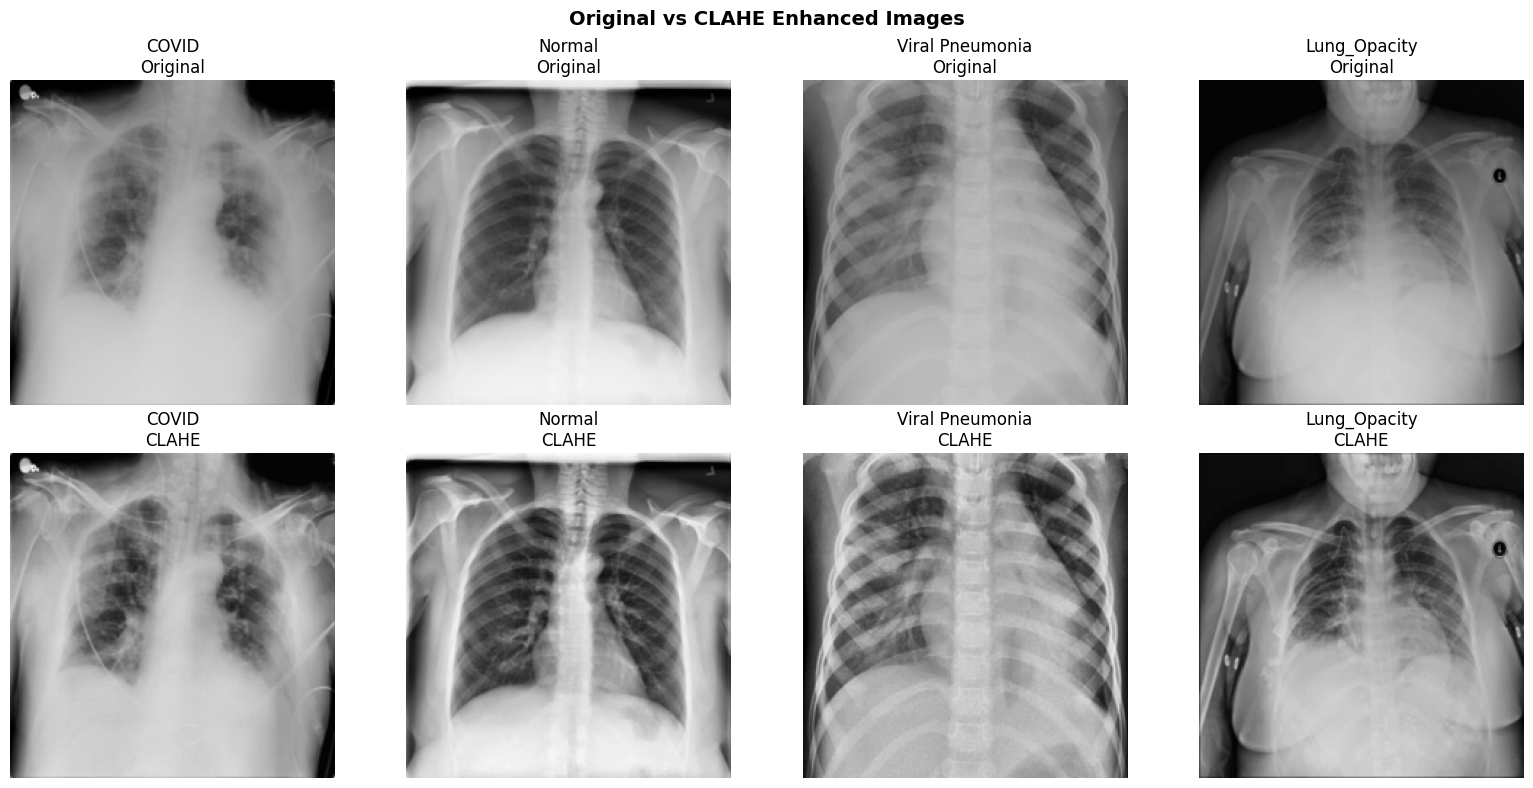

In [ ]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fig.suptitle("Original vs CLAHE Enhanced Images", fontsize=14, fontweight="bold")

for i, cls in enumerate(class_names):
    img_path = valid_images[cls][0]

    original = cv2.cvtColor(cv2.imread(img_path), cv2.COLOR_BGR2RGB)
    original = cv2.resize(original, (IMG_SIZE, IMG_SIZE))

    enhanced = apply_clahe_and_resize(img_path)

    axes[0, i].imshow(original)
    axes[0, i].set_title(f"{cls}\nOriginal")
    axes[0, i].axis("off")

    axes[1, i].imshow(enhanced)
    axes[1, i].set_title(f"{cls}\nCLAHE")
    axes[1, i].axis("off")

plt.tight_layout()
plt.show()

Cell 8 Build balanced dataset

In [ ]:
X = []
y = []

label_map = {cls: i for i, cls in enumerate(class_names)}

for cls in class_names:
    selected_paths = valid_images[cls][:SAMPLES_PER_CLASS]
    print(f"Loading {cls}: {len(selected_paths)}")

    for path in selected_paths:
        try:
            img = apply_clahe_and_resize(path)
            X.append(img)
            y.append(label_map[cls])
        except:
            pass

X = np.array(X, dtype=np.uint8)
y = np.array(y)

print("X shape:", X.shape)
print("y shape:", y.shape)

Loading COVID: 800
Loading Normal: 800
Loading Viral Pneumonia: 800
Loading Lung_Opacity: 800
X shape: (3200, 224, 224, 3)
y shape: (3200,)


Cell 9 Split into train, validation, test

In [ ]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.30,
    random_state=SEED,
    stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,
    random_state=SEED,
    stratify=y_temp
)

print("Train:", X_train.shape, y_train.shape)
print("Validation:", X_val.shape, y_val.shape)
print("Test:", X_test.shape, y_test.shape)

Train: (2240, 224, 224, 3) (2240,)
Validation: (480, 224, 224, 3) (480,)
Test: (480, 224, 224, 3) (480,)


Cell 10 Compute class weights

In [ ]:
class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train),
    y=y_train
)

class_weights = dict(enumerate(class_weights))
print("Class weights:", class_weights)

Class weights: {0: np.float64(1.0), 1: np.float64(1.0), 2: np.float64(1.0), 3: np.float64(1.0)}


Cell 11 EfficientNet preprocessing

In [ ]:
X_train_eff = effnet_preprocess(X_train.astype(np.float32))
X_val_eff = effnet_preprocess(X_val.astype(np.float32))
X_test_eff = effnet_preprocess(X_test.astype(np.float32))

print("EfficientNet preprocessing complete")

EfficientNet preprocessing complete


Cell 12 Data augmentation

In [ ]:
train_datagen = ImageDataGenerator(
    rotation_range=15,
    zoom_range=0.15,
    width_shift_range=0.10,
    height_shift_range=0.10,
    horizontal_flip=True
)

val_datagen = ImageDataGenerator()

train_gen = train_datagen.flow(X_train_eff, y_train, batch_size=BATCH_SIZE, shuffle=True)
val_gen = val_datagen.flow(X_val_eff, y_val, batch_size=BATCH_SIZE, shuffle=False)

print("Generators ready")

Generators ready


Cell 13 Build EfficientNetB0 model

In [ ]:
base_model = EfficientNetB0(
    weights="imagenet",
    include_top=False,
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)

for layer in base_model.layers:
    layer.trainable = False

x = GlobalAveragePooling2D()(base_model.output)
x = BatchNormalization()(x)
x = Dense(256, activation="relu")(x)
x = Dropout(0.4)(x)
outputs = Dense(len(class_names), activation="softmax")(x)

model = Model(inputs=base_model.input, outputs=outputs)

model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_2         │ (None, 224, 224,  │          0 │ input_layer_1[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization_1     │ (None, 224, 224,  │          7 │ rescaling_2[0][0] │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_3         │ (None, 224, 224,  │          0 │ normalization_1[… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 225, 225,  │          0 │ rescaling_3[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 112, 112,  │        864 │ stem_conv_pad[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 112, 112,  │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 112, 112,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 112, 112,  │        288 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 112, 112,  │        128 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 112, 112,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 32)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 32)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 8)   │        264 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 32)  │        288 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 112, 112,  │          0 │ block1a_activati… │
│ (Multiply)          │ 32)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 112, 112,  │        512 │ block1a_se_excit

 Total params: 4,383,655 (16.72 MB)

 Trainable params: 331,524 (1.26 MB)

 Non-trainable params: 4,052,131 (15.46 MB)

Cell 14 Train head only

In [ ]:
callbacks = [
    EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True),
    ReduceLROnPlateau(monitor="val_loss", factor=0.3, patience=2, verbose=1),
    ModelCheckpoint("best_effnet_head.keras", monitor="val_loss", save_best_only=True)
]

history_head = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=8,
    class_weight=class_weights,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/8
140/140 ━━━━━━━━━━━━━━━━━━━━ 15s 88ms/step - accuracy: 0.6572 - loss: 1.3516 - val_accuracy: 0.7396 - val_loss: 0.6450 - learning_rate: 0.0010
Epoch 2/8
140/140 ━━━━━━━━━━━━━━━━━━━━ 10s 74ms/step - accuracy: 0.7588 - loss: 0.9862 - val_accuracy: 0.7750 - val_loss: 0.6259 - learning_rate: 0.0010
Epoch 3/8
140/140 ━━━━━━━━━━━━━━━━━━━━ 11s 78ms/step - accuracy: 0.7721 - loss: 0.9559 - val_accuracy: 0.8354 - val_loss: 0.4593 - learning_rate: 0.0010
Epoch 4/8
140/140 ━━━━━━━━━━━━━━━━━━━━ 10s 74ms/step - accuracy: 0.7709 - loss: 0.8564 - val_accuracy: 0.8188 - val_loss: 0.6110 - learning_rate: 0.0010
Epoch 5/8
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - accuracy: 0.8000 - loss: 0.7277
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0003000000142492354.
140/140 ━━━━━━━━━━━━━━━━━━━━ 10s 74ms/step - accuracy: 0.7999 - loss: 0.7275 - val_accuracy: 0.8375 - val_loss: 0.4831 - learning_rate: 0.0010
Epoch 6/8
140/140 ━━━━━━━━━━━━━━━━━━━━ 11s 76ms/step - accuracy: 0.8126 - loss: 0.6

Cell 15 Fine-tune top layers

In [ ]:
for layer in base_model.layers[-30:]:
    layer.trainable = True

model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

callbacks_fine = [
    EarlyStopping(monitor="val_loss", patience=4, restore_best_weights=True),
    ReduceLROnPlateau(monitor="val_loss", factor=0.3, patience=2, verbose=1),
    ModelCheckpoint("best_effnet_fine.keras", monitor="val_loss", save_best_only=True)
]

history_fine = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=8,
    class_weight=class_weights,
    callbacks=callbacks_fine,
    verbose=1
)

Epoch 1/8
140/140 ━━━━━━━━━━━━━━━━━━━━ 25s 142ms/step - accuracy: 0.7572 - loss: 0.7050 - val_accuracy: 0.8292 - val_loss: 0.4895 - learning_rate: 1.0000e-05
Epoch 2/8
140/140 ━━━━━━━━━━━━━━━━━━━━ 20s 145ms/step - accuracy: 0.7705 - loss: 0.6758 - val_accuracy: 0.8229 - val_loss: 0.4814 - learning_rate: 1.0000e-05
Epoch 3/8
140/140 ━━━━━━━━━━━━━━━━━━━━ 25s 179ms/step - accuracy: 0.7913 - loss: 0.6328 - val_accuracy: 0.8333 - val_loss: 0.4550 - learning_rate: 1.0000e-05
Epoch 4/8
140/140 ━━━━━━━━━━━━━━━━━━━━ 23s 164ms/step - accuracy: 0.7780 - loss: 0.5886 - val_accuracy: 0.8417 - val_loss: 0.4564 - learning_rate: 1.0000e-05
Epoch 5/8
140/140 ━━━━━━━━━━━━━━━━━━━━ 24s 167ms/step - accuracy: 0.7891 - loss: 0.6057 - val_accuracy: 0.8354 - val_loss: 0.4521 - learning_rate: 1.0000e-05
Epoch 6/8
140/140 ━━━━━━━━━━━━━━━━━━━━ 65s 466ms/step - accuracy: 0.7970 - loss: 0.6274 - val_accuracy: 0.8417 - val_loss: 0.4396 - learning_rate: 1.0000e-05
Epoch 7/8
140/140 ━━━━━━━━━━━━━━━━━━━━ 18s 127ms/ste

Cell 16 Evaluate on test set

In [ ]:
test_loss, test_acc = model.evaluate(X_test_eff, y_test, verbose=0)
print("EfficientNetB0 Test Accuracy:", test_acc)
print("EfficientNetB0 Test Loss:", test_loss)

EfficientNetB0 Test Accuracy: 0.8541666865348816
EfficientNetB0 Test Loss: 0.4272004961967468


Cell 17 Classification report

In [ ]:
y_prob = model.predict(X_test_eff, verbose=0)
y_pred = np.argmax(y_prob, axis=1)

print(classification_report(y_test, y_pred, target_names=class_names))

                 precision    recall  f1-score   support

          COVID       0.87      0.85      0.86       120
         Normal       0.77      0.85      0.81       120
Viral Pneumonia       0.98      0.95      0.97       120
   Lung_Opacity       0.81      0.77      0.79       120

       accuracy                           0.85       480
      macro avg       0.86      0.85      0.85       480
   weighted avg       0.86      0.85      0.85       480



Cell 18  Confusion matrix

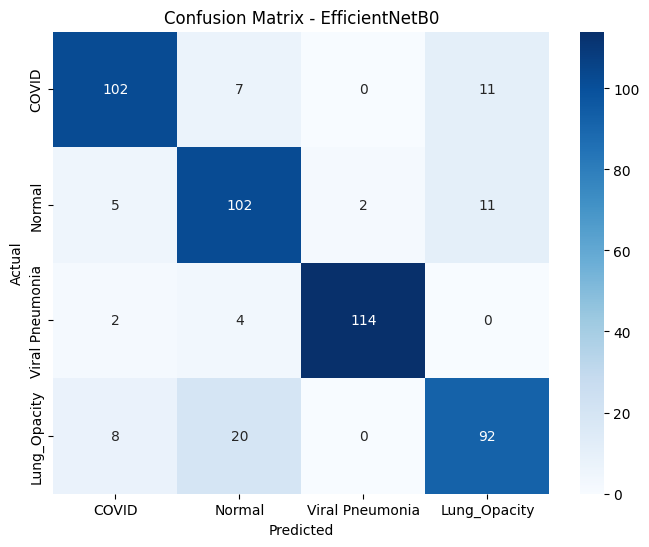

In [ ]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - EfficientNetB0")
plt.show()

Cell 19 Load best head-only model

In [ ]:
from tensorflow.keras.models import load_model

best_effnet = load_model("best_effnet_head.keras")
print("Best head-only EfficientNetB0 model loaded")

Best head-only EfficientNetB0 model loaded


Cell 20 Evaluate best head-only model

In [ ]:
best_loss, best_acc = best_effnet.evaluate(X_test_eff, y_test, verbose=0)
print("Best EfficientNetB0 Test Accuracy:", best_acc)
print("Best EfficientNetB0 Test Loss:", best_loss)

Best EfficientNetB0 Test Accuracy: 0.862500011920929
Best EfficientNetB0 Test Loss: 0.3983828127384186


Cell 21 Classification report for best model

In [ ]:
y_prob_best = best_effnet.predict(X_test_eff, verbose=0)
y_pred_best = np.argmax(y_prob_best, axis=1)

print(classification_report(y_test, y_pred_best, target_names=class_names))

                 precision    recall  f1-score   support

          COVID       0.91      0.84      0.87       120
         Normal       0.77      0.84      0.80       120
Viral Pneumonia       0.95      0.97      0.96       120
   Lung_Opacity       0.83      0.79      0.81       120

       accuracy                           0.86       480
      macro avg       0.86      0.86      0.86       480
   weighted avg       0.86      0.86      0.86       480



Cell 22 Confusion matrix for best model

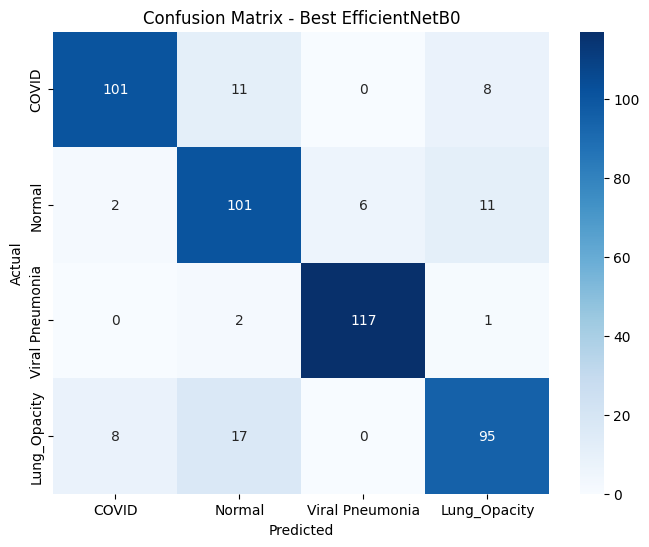

In [ ]:
cm_best = confusion_matrix(y_test, y_pred_best)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_best, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Best EfficientNetB0")
plt.show()

Cell 23 Save EfficientNetB0 results

In [ ]:
report_best = classification_report(
    y_test, y_pred_best, target_names=class_names, output_dict=True
)

effnet_results = pd.DataFrame([{
    "Model": "EfficientNetB0",
    "Accuracy": report_best["accuracy"],
    "Precision": report_best["macro avg"]["precision"],
    "Recall": report_best["macro avg"]["recall"],
    "F1-score": report_best["macro avg"]["f1-score"]
}])

effnet_results.to_csv("efficientnetb0_results.csv", index=False)
effnet_results

,Model,Accuracy,Precision,Recall,F1-score
0,EfficientNetB0,0.8625,0.864552,0.8625,0.862678


Cell 24 Import VGG19 preprocessing

In [ ]:
from tensorflow.keras.applications import VGG19
from tensorflow.keras.applications.vgg19 import preprocess_input as vgg_preprocess

Cell 25 Preprocess data for VGG19

In [ ]:
X_train_vgg = vgg_preprocess(X_train.astype(np.float32))
X_val_vgg = vgg_preprocess(X_val.astype(np.float32))
X_test_vgg = vgg_preprocess(X_test.astype(np.float32))

print("VGG19 preprocessing complete")
print("Train shape:", X_train_vgg.shape)
print("Validation shape:", X_val_vgg.shape)
print("Test shape:", X_test_vgg.shape)

VGG19 preprocessing complete
Train shape: (2240, 224, 224, 3)
Validation shape: (480, 224, 224, 3)
Test shape: (480, 224, 224, 3)


Cell 26 Create generators for VGG19

In [ ]:
train_gen_vgg = train_datagen.flow(
    X_train_vgg, y_train,
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_gen_vgg = val_datagen.flow(
    X_val_vgg, y_val,
    batch_size=BATCH_SIZE,
    shuffle=False
)

print("VGG19 generators ready")

VGG19 generators ready


Cell 27 Build VGG19 model

In [ ]:
base_model_vgg = VGG19(
    weights="imagenet",
    include_top=False,
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)

for layer in base_model_vgg.layers:
    layer.trainable = False

x = GlobalAveragePooling2D()(base_model_vgg.output)
x = BatchNormalization()(x)
x = Dense(512, activation="relu")(x)
x = Dropout(0.5)(x)
outputs_vgg = Dense(len(class_names), activation="softmax")(x)

model_vgg = Model(inputs=base_model_vgg.input, outputs=outputs_vgg)

model_vgg.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model_vgg.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv4 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv4 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv4 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │             

 Total params: 20,291,140 (77.40 MB)

 Trainable params: 265,732 (1.01 MB)

 Non-trainable params: 20,025,408 (76.39 MB)

Cell 28 Train VGG19 head

In [ ]:
callbacks_vgg = [
    EarlyStopping(monitor="val_loss", patience=4, restore_best_weights=True),
    ReduceLROnPlateau(monitor="val_loss", factor=0.3, patience=2, verbose=1),
    ModelCheckpoint("best_vgg19_head.keras", monitor="val_loss", save_best_only=True)
]

history_vgg = model_vgg.fit(
    train_gen_vgg,
    validation_data=val_gen_vgg,
    epochs=12,
    class_weight=class_weights,
    callbacks=callbacks_vgg,
    verbose=1
)

Epoch 1/12
140/140 ━━━━━━━━━━━━━━━━━━━━ 37s 258ms/step - accuracy: 0.4524 - loss: 1.7266 - val_accuracy: 0.7396 - val_loss: 0.7310 - learning_rate: 1.0000e-04
Epoch 2/12
140/140 ━━━━━━━━━━━━━━━━━━━━ 44s 312ms/step - accuracy: 0.6795 - loss: 0.9468 - val_accuracy: 0.7542 - val_loss: 0.6757 - learning_rate: 1.0000e-04
Epoch 3/12
140/140 ━━━━━━━━━━━━━━━━━━━━ 47s 339ms/step - accuracy: 0.7207 - loss: 0.7770 - val_accuracy: 0.7729 - val_loss: 0.6680 - learning_rate: 1.0000e-04
Epoch 4/12
140/140 ━━━━━━━━━━━━━━━━━━━━ 43s 304ms/step - accuracy: 0.7507 - loss: 0.7202 - val_accuracy: 0.7854 - val_loss: 0.6227 - learning_rate: 1.0000e-04
Epoch 5/12
140/140 ━━━━━━━━━━━━━━━━━━━━ 40s 289ms/step - accuracy: 0.7610 - loss: 0.6784 - val_accuracy: 0.7958 - val_loss: 0.6261 - learning_rate: 1.0000e-04
Epoch 6/12
140/140 ━━━━━━━━━━━━━━━━━━━━ 43s 306ms/step - accuracy: 0.7806 - loss: 0.6334 - val_accuracy: 0.8125 - val_loss: 0.5869 - learning_rate: 1.0000e-04
Epoch 7/12
140/140 ━━━━━━━━━━━━━━━━━━━━ 42s 30

Cell 29 Load best VGG19 model

In [ ]:
best_vgg = load_model("best_vgg19_head.keras")
print("Best VGG19 model loaded")

Best VGG19 model loaded


Cell 30 Evaluate VGG19

In [ ]:
vgg_loss, vgg_acc = best_vgg.evaluate(X_test_vgg, y_test, verbose=0)
print("VGG19 Test Accuracy:", vgg_acc)
print("VGG19 Test Loss:", vgg_loss)

VGG19 Test Accuracy: 0.824999988079071
VGG19 Test Loss: 0.49110350012779236


Cell 31 VGG19 classification report

In [ ]:
y_prob_vgg = best_vgg.predict(X_test_vgg, verbose=0)
y_pred_vgg = np.argmax(y_prob_vgg, axis=1)

print(classification_report(y_test, y_pred_vgg, target_names=class_names))

                 precision    recall  f1-score   support

          COVID       0.80      0.75      0.77       120
         Normal       0.73      0.83      0.78       120
Viral Pneumonia       0.98      0.94      0.96       120
   Lung_Opacity       0.81      0.78      0.79       120

       accuracy                           0.82       480
      macro avg       0.83      0.83      0.83       480
   weighted avg       0.83      0.82      0.83       480



Cell 32 VGG19 confusion matrix

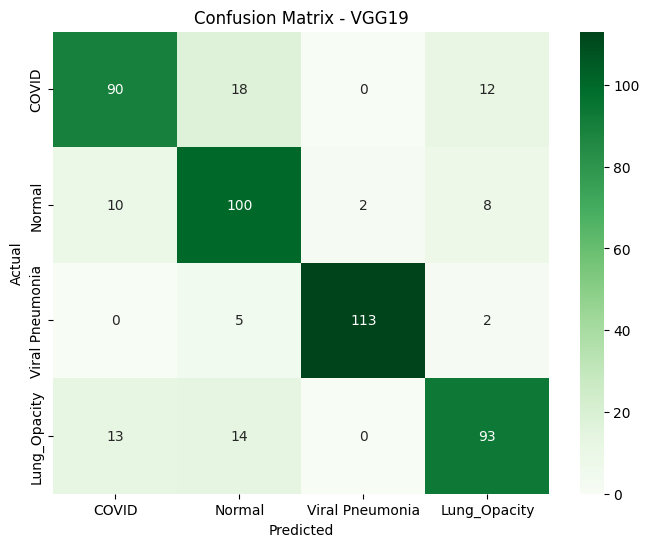

In [ ]:
cm_vgg = confusion_matrix(y_test, y_pred_vgg)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_vgg, annot=True, fmt="d", cmap="Greens",
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - VGG19")
plt.show()

Cell 33 Save EfficientNetB0 and VGG19 results

In [ ]:
report_vgg = classification_report(
    y_test, y_pred_vgg, target_names=class_names, output_dict=True
)

comparison_df = pd.DataFrame([
    {
        "Model": "EfficientNetB0",
        "Accuracy": report_best["accuracy"],
        "Precision": report_best["macro avg"]["precision"],
        "Recall": report_best["macro avg"]["recall"],
        "F1-score": report_best["macro avg"]["f1-score"]
    },
    {
        "Model": "VGG19",
        "Accuracy": report_vgg["accuracy"],
        "Precision": report_vgg["macro avg"]["precision"],
        "Recall": report_vgg["macro avg"]["recall"],
        "F1-score": report_vgg["macro avg"]["f1-score"]
    }
])

comparison_df.to_csv("effnet_vgg_comparison.csv", index=False)
comparison_df

,Model,Accuracy,Precision,Recall,F1-score
0,EfficientNetB0,0.8625,0.864552,0.8625,0.862678
1,VGG19,0.8250,0.829423,0.8250,0.825983


Cell 34 Preprocess for ResNet50

In [ ]:
from tensorflow.keras.applications.resnet50 import preprocess_input as resnet_preprocess
import numpy as np

X_train_res = resnet_preprocess(X_train.astype(np.float32))
X_val_res   = resnet_preprocess(X_val.astype(np.float32))
X_test_res  = resnet_preprocess(X_test.astype(np.float32))

print("ResNet50 preprocessing complete")
print("Train:", X_train_res.shape)
print("Validation:", X_val_res.shape)
print("Test:", X_test_res.shape)

ResNet50 preprocessing complete
Train: (2240, 224, 224, 3)
Validation: (480, 224, 224, 3)
Test: (480, 224, 224, 3)


Cell 35 ResNet50 generators

In [ ]:
train_gen_res = train_datagen.flow(
    X_train_res,
    y_train,
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_gen_res = val_datagen.flow(
    X_val_res,
    y_val,
    batch_size=BATCH_SIZE,
    shuffle=False
)

print("ResNet50 generators ready")

ResNet50 generators ready


Cell 36 Build ResNet50

In [ ]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D, BatchNormalization, Dense, Dropout
from tensorflow.keras.optimizers import Adam

base_model_res = ResNet50(
    weights="imagenet",
    include_top=False,
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)

for layer in base_model_res.layers:
    layer.trainable = False

x = GlobalAveragePooling2D()(base_model_res.output)
x = BatchNormalization()(x)
x = Dense(256, activation="relu")(x)
x = Dropout(0.4)(x)
outputs_res = Dense(len(class_names), activation="softmax")(x)

model_res = Model(inputs=base_model_res.input, outputs=outputs_res)

model_res.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("ResNet50 model ready")
model_res.summary()

ResNet50 model ready


Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer_3[0]… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 24,121,476 (92.02 MB)

 Trainable params: 529,668 (2.02 MB)

 Non-trainable params: 23,591,808 (90.00 MB)

Cell 37 Train ResNet50 head only

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

callbacks_res = [
    EarlyStopping(
        monitor="val_loss",
        patience=3,
        restore_best_weights=True
    ),
    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.3,
        patience=2,
        verbose=1
    ),
    ModelCheckpoint(
        "best_resnet50_head.keras",
        monitor="val_loss",
        save_best_only=True
    )
]

history_res = model_res.fit(
    train_gen_res,
    validation_data=val_gen_res,
    epochs=8,
    callbacks=callbacks_res,
    verbose=1
)

Epoch 1/8
140/140 ━━━━━━━━━━━━━━━━━━━━ 37s 225ms/step - accuracy: 0.5608 - loss: 1.4755 - val_accuracy: 0.7854 - val_loss: 0.6086 - learning_rate: 1.0000e-04
Epoch 2/8
140/140 ━━━━━━━━━━━━━━━━━━━━ 25s 177ms/step - accuracy: 0.7088 - loss: 0.9053 - val_accuracy: 0.8021 - val_loss: 0.5772 - learning_rate: 1.0000e-04
Epoch 3/8
140/140 ━━━━━━━━━━━━━━━━━━━━ 25s 178ms/step - accuracy: 0.7798 - loss: 0.6943 - val_accuracy: 0.8208 - val_loss: 0.5249 - learning_rate: 1.0000e-04
Epoch 4/8
140/140 ━━━━━━━━━━━━━━━━━━━━ 23s 163ms/step - accuracy: 0.7949 - loss: 0.6704 - val_accuracy: 0.8354 - val_loss: 0.5164 - learning_rate: 1.0000e-04
Epoch 5/8
140/140 ━━━━━━━━━━━━━━━━━━━━ 22s 158ms/step - accuracy: 0.8089 - loss: 0.5859 - val_accuracy: 0.8562 - val_loss: 0.4848 - learning_rate: 1.0000e-04
Epoch 6/8
140/140 ━━━━━━━━━━━━━━━━━━━━ 25s 179ms/step - accuracy: 0.7994 - loss: 0.6151 - val_accuracy: 0.8458 - val_loss: 0.5193 - learning_rate: 1.0000e-04
Epoch 7/8
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 130ms/step

Cell 38 Fine-tune ResNet50 top layers

In [ ]:
for layer in base_model_res.layers[-20:]:
    if not isinstance(layer, BatchNormalization):
        layer.trainable = True

for layer in base_model_res.layers[:-20]:
    layer.trainable = False

model_res.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

callbacks_res_fine = [
    EarlyStopping(
        monitor="val_loss",
        patience=4,
        restore_best_weights=True
    ),
    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.3,
        patience=2,
        verbose=1
    ),
    ModelCheckpoint(
        "best_resnet50_fine.keras",
        monitor="val_loss",
        save_best_only=True
    )
]

history_res_fine = model_res.fit(
    train_gen_res,
    validation_data=val_gen_res,
    epochs=8,
    callbacks=callbacks_res_fine,
    verbose=1
)

Epoch 1/8
140/140 ━━━━━━━━━━━━━━━━━━━━ 31s 204ms/step - accuracy: 0.8121 - loss: 0.6014 - val_accuracy: 0.8562 - val_loss: 0.4281 - learning_rate: 1.0000e-05
Epoch 2/8
140/140 ━━━━━━━━━━━━━━━━━━━━ 26s 182ms/step - accuracy: 0.8467 - loss: 0.4798 - val_accuracy: 0.8604 - val_loss: 0.4299 - learning_rate: 1.0000e-05
Epoch 3/8
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 157ms/step - accuracy: 0.8272 - loss: 0.5084
Epoch 3: ReduceLROnPlateau reducing learning rate to 2.9999999242136253e-06.
140/140 ━━━━━━━━━━━━━━━━━━━━ 25s 181ms/step - accuracy: 0.8272 - loss: 0.5084 - val_accuracy: 0.8542 - val_loss: 0.5148 - learning_rate: 1.0000e-05
Epoch 4/8
140/140 ━━━━━━━━━━━━━━━━━━━━ 25s 180ms/step - accuracy: 0.8555 - loss: 0.4482 - val_accuracy: 0.8604 - val_loss: 0.4534 - learning_rate: 3.0000e-06
Epoch 5/8
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 155ms/step - accuracy: 0.8466 - loss: 0.4530
Epoch 5: ReduceLROnPlateau reducing learning rate to 8.999999636216671e-07.
140/140 ━━━━━━━━━━━━━━━━━━━━ 25s 179ms/step - accur

Cell 39 Evaluate ResNet50

In [ ]:
from tensorflow.keras.models import load_model

best_res = load_model("best_resnet50_fine.keras")

res_loss, res_acc = best_res.evaluate(X_test_res, y_test, verbose=0)

print("ResNet50 Test Accuracy:", res_acc)
print("ResNet50 Test Loss:", res_loss)

ResNet50 Test Accuracy: 0.8583333492279053
ResNet50 Test Loss: 0.3826349079608917


Cell 40 ResNet50 classification report and confusion matrix

                 precision    recall  f1-score   support

          COVID       0.84      0.87      0.85       120
         Normal       0.77      0.84      0.80       120
Viral Pneumonia       0.97      0.97      0.97       120
   Lung_Opacity       0.87      0.75      0.80       120

       accuracy                           0.86       480
      macro avg       0.86      0.86      0.86       480
   weighted avg       0.86      0.86      0.86       480



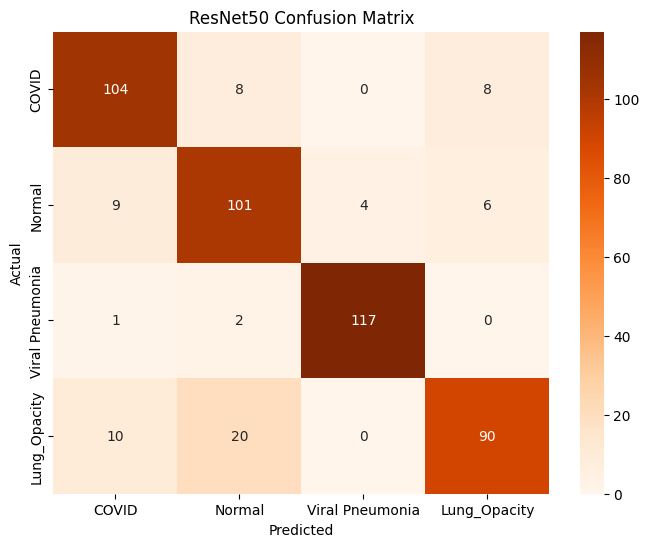

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

y_prob_res = best_res.predict(X_test_res, verbose=0)
y_pred_res = np.argmax(y_prob_res, axis=1)

print(classification_report(y_test, y_pred_res, target_names=class_names))

cm_res = confusion_matrix(y_test, y_pred_res)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm_res,
    annot=True,
    fmt="d",
    cmap="Oranges",
    xticklabels=class_names,
    yticklabels=class_names
)
plt.title("ResNet50 Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

Cell 41 Training curves

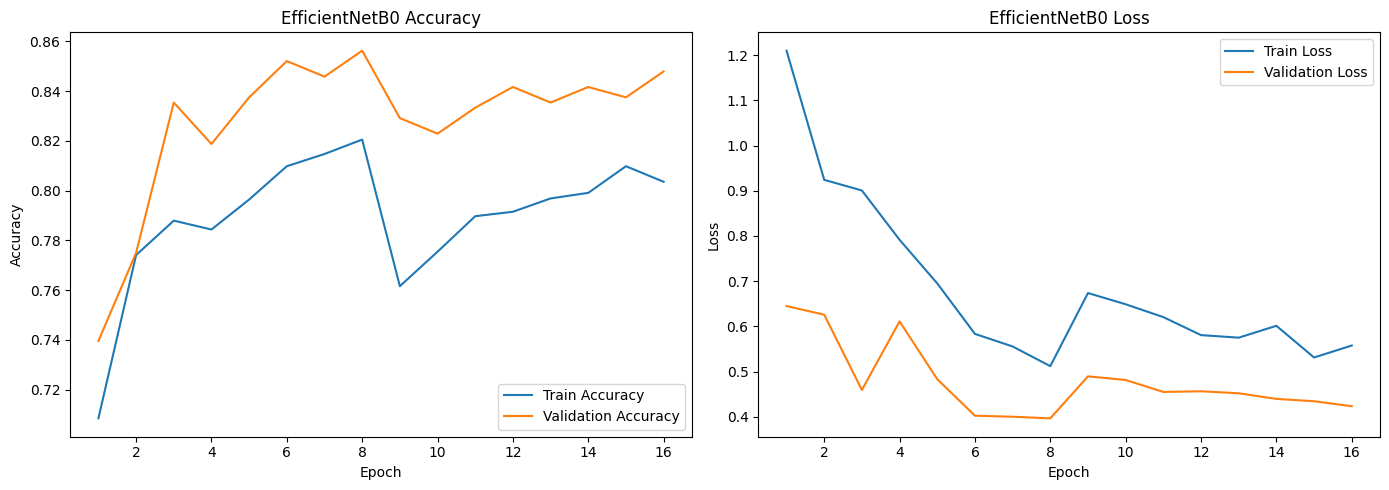

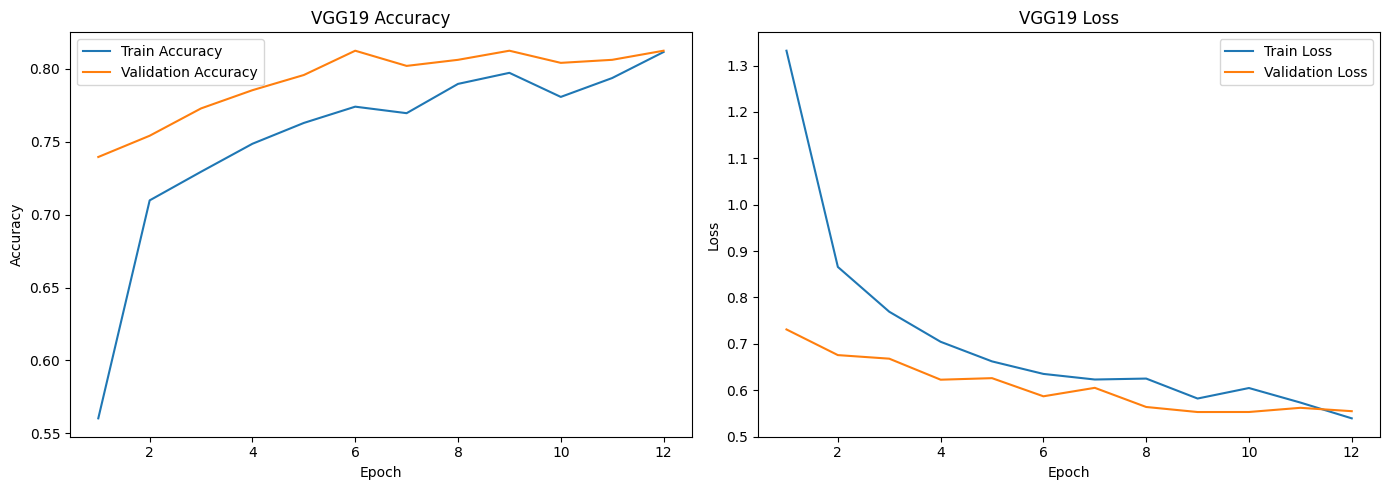

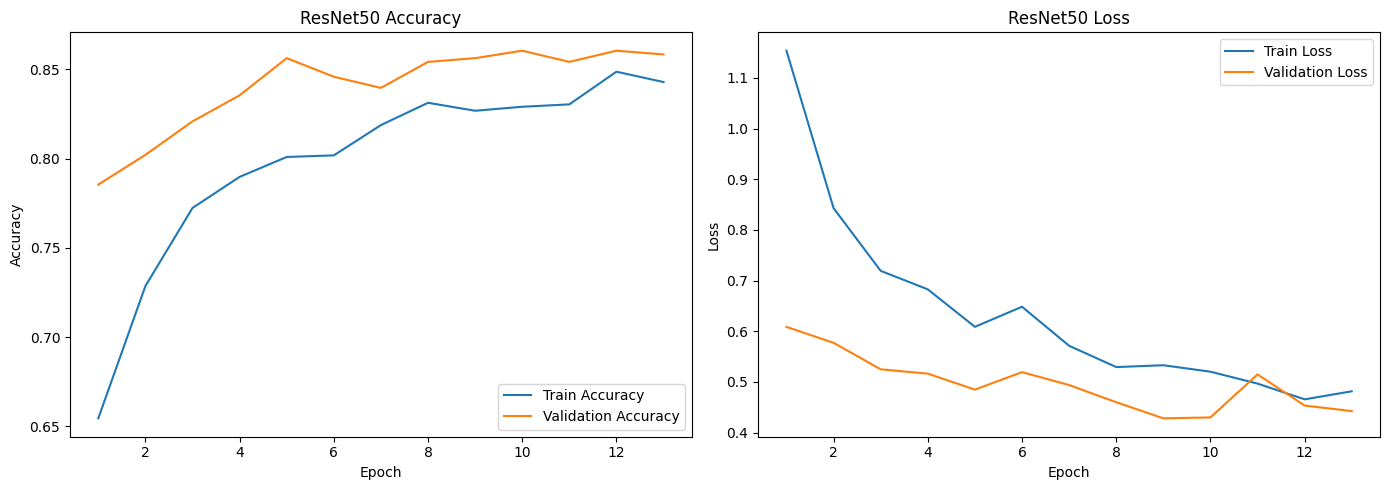

Training history plots generated successfully.


In [ ]:


import matplotlib.pyplot as plt

def plot_history(history1, history2=None, title="Model"):
    acc = list(history1.history.get("accuracy", []))
    val_acc = list(history1.history.get("val_accuracy", []))
    loss = list(history1.history.get("loss", []))
    val_loss = list(history1.history.get("val_loss", []))

    if history2 is not None:
        acc.extend(history2.history.get("accuracy", []))
        val_acc.extend(history2.history.get("val_accuracy", []))
        loss.extend(history2.history.get("loss", []))
        val_loss.extend(history2.history.get("val_loss", []))

    epochs = range(1, len(acc) + 1)

    plt.figure(figsize=(14, 5))

    plt.subplot(1, 2, 1)
    plt.plot(epochs, acc, label="Train Accuracy")
    plt.plot(epochs, val_acc, label="Validation Accuracy")
    plt.title(f"{title} Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(epochs, loss, label="Train Loss")
    plt.plot(epochs, val_loss, label="Validation Loss")
    plt.title(f"{title} Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()

    plt.tight_layout()
    plt.show()


# EfficientNetB0
if "history_head" in globals() and "history_fine" in globals():
    plot_history(history_head, history_fine, "EfficientNetB0")
elif "history_eff_head" in globals() and "history_eff_fine" in globals():
    plot_history(history_eff_head, history_eff_fine, "EfficientNetB0")
elif "history_effnet" in globals():
    plot_history(history_effnet, title="EfficientNetB0")
else:
    print("EfficientNetB0 history not found")


# VGG19
if "history_vgg19" in globals():
    plot_history(history_vgg19, title="VGG19")
elif "history_vgg" in globals():
    plot_history(history_vgg, title="VGG19")
else:
    print("VGG19 history not found")


# ResNet50
if "history_res" in globals() and "history_res_fine" in globals():
    plot_history(history_res, history_res_fine, "ResNet50")
elif "history_resnet50" in globals():
    plot_history(history_resnet50, title="ResNet50")
elif "history_res" in globals():
    plot_history(history_res, title="ResNet50")
else:
    print("ResNet50 history not found")

print("Training history plots generated successfully.")

In [ ]:
# Check which test-label variable exists
for name in ["ytest", "y_test", "yTest", "Y_test", "yval", "ytrain"]:
    if name in globals():
        print(name, type(globals()[name]), getattr(globals()[name], "shape", "no shape"))

y_test <class 'numpy.ndarray'> (480,)


In [ ]:
print(type(y_test))
print(y_test.shape)
print(np.unique(y_test))
print(pd.Series(y_test).value_counts().sort_index())

<class 'numpy.ndarray'>
(480,)
[0 1 2 3]
0    120
1    120
2    120
3    120
Name: count, dtype: int64


In [ ]:
print(label_map)
print(np.unique(y_pred, return_counts=True))

{'COVID': 0, 'Normal': 1, 'Viral Pneumonia': 2, 'Lung_Opacity': 3}
(array([0, 1, 2, 3]), array([117, 133, 116, 114]))


Cell 42 Final comparison table

In [ ]:
# Cell 37 — Aggregate Evaluation Metrics into df_results
import pandas as pd
import numpy as np
from tensorflow.keras.models import load_model

all_metrics = []

# 1. Load and Evaluate EfficientNetB0
print("Loading best EfficientNetB0...")
best_eff = load_model("best_effnet_fine.keras")
eff_loss, eff_acc = best_eff.evaluate(X_test_eff, y_test, verbose=0)
all_metrics.append({"Model": "EfficientNetB0", "Accuracy": eff_acc})

# 2. Load and Evaluate VGG19
print("Loading best VGG19...")
# Note: VGG was saved under _head in your notebook, not _fine
best_vgg = load_model("best_vgg19_head.keras")
vgg_loss, vgg_acc = best_vgg.evaluate(X_test_vgg, y_test, verbose=0)
all_metrics.append({"Model": "VGG19", "Accuracy": vgg_acc})

# 3. Load and Evaluate ResNet50
print("Loading best ResNet50...")
best_res = load_model("best_resnet50_fine.keras")
res_loss, res_acc = best_res.evaluate(X_test_res, y_test, verbose=0)
all_metrics.append({"Model": "ResNet50", "Accuracy": res_acc})

# Build the DataFrame
df_results = pd.DataFrame(all_metrics).set_index("Model")

print("\nAll models evaluated successfully.")
display(df_results)

# Save to CSV
df_results.to_csv("model_comparison_results_fixed.csv")
print("Saved: model_comparison_results_fixed.csv")

Loading best EfficientNetB0...
Loading best VGG19...
Loading best ResNet50...

All models evaluated successfully.


,Accuracy
Model,
EfficientNetB0,0.854167
VGG19,0.825000
ResNet50,0.858333


Saved: model_comparison_results_fixed.csv


Cell 43 Accuracy comparison plot

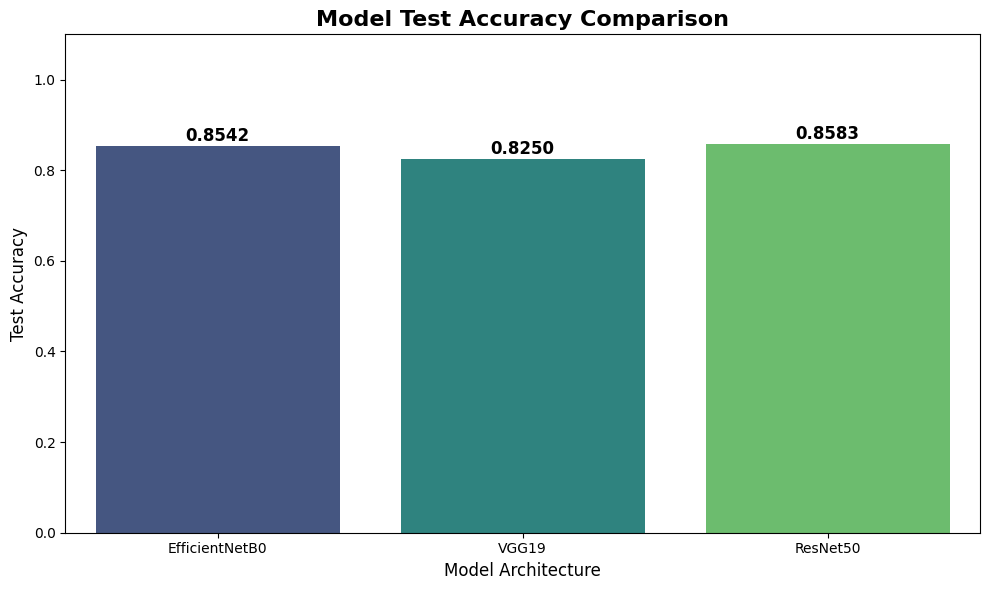

In [ ]:
# Cell 38 — Accuracy Comparison Plot
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))

# Plot bars using the index (Model names) and Accuracy column
barplot = sns.barplot(
    x=df_results.index,
    y=df_results["Accuracy"].values,
    palette="viridis"
)

plt.title("Model Test Accuracy Comparison", fontsize=16, fontweight='bold')
plt.ylabel("Test Accuracy", fontsize=12)
plt.xlabel("Model Architecture", fontsize=12)

# Annotate bars with accuracy numbers
for i, val in enumerate(df_results["Accuracy"].values):
    plt.text(i, val + 0.01, f"{val:.4f}", ha="center", fontsize=12, fontweight='bold')

plt.ylim(0, 1.1)
plt.tight_layout()
plt.show()

Cell 44 ROC curves

Generating predictions for ROC curves...


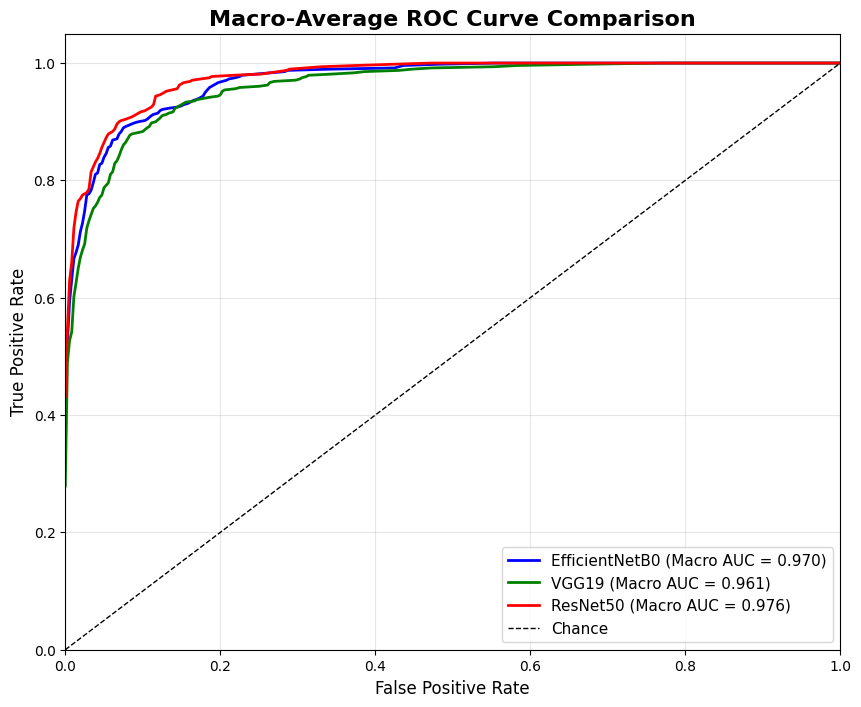

In [ ]:
# ROC Curves for EfficientNetB0, VGG19, and ResNet50

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

# Load saved models if not already loaded
import os
from tensorflow.keras.models import load_model
if 'best_eff' not in globals() and os.path.exists("best_effnet_fine.keras"):
    print("Loading saved EfficientNetB0...")
    globals()['best_eff'] = load_model("best_effnet_fine.keras")
if 'best_vgg' not in globals() and os.path.exists("best_vgg19_head.keras"):
    print("Loading saved VGG19...")
    globals()['best_vgg'] = load_model("best_vgg19_head.keras")
if 'best_res' not in globals() and os.path.exists("best_resnet50_fine.keras"):
    print("Loading saved ResNet50...")
    globals()['best_res'] = load_model("best_resnet50_fine.keras")

# Preprocess test data for VGG and ResNet if needed
if 'X_test_vgg' not in globals() and 'X_test' in globals():
    print("Preprocessing test data for VGG19...")
    from tensorflow.keras.applications.vgg19 import preprocess_input as vgg_preprocess
    globals()['X_test_vgg'] = vgg_preprocess(X_test.astype(np.float32))
if 'X_test_res' not in globals() and 'X_test' in globals():
    print("Preprocessing test data for ResNet50...")
    from tensorflow.keras.applications.resnet50 import preprocess_input as resnet_preprocess
    globals()['X_test_res'] = resnet_preprocess(X_test.astype(np.float32))

# Check required variables from your notebook
required_vars = [
    "y_test", "class_names",
    "best_eff", "best_vgg", "best_res",
    "X_test_eff", "X_test_vgg", "X_test_res"
]

missing = [v for v in required_vars if v not in globals()]
if missing:
    raise NameError(f"Missing variables: {missing}. Run the split/model-loading cells first.")

# Binarize test labels for multiclass ROC
ytest_bin = label_binarize(y_test, classes=np.arange(len(class_names)))
n_classes = ytest_bin.shape[1]

# Predict probabilities
print("Generating predictions for ROC curves...")
probs_eff = best_eff.predict(X_test_eff, verbose=0)
probs_vgg = best_vgg.predict(X_test_vgg, verbose=0)
probs_res = best_res.predict(X_test_res, verbose=0)

model_probs = {
    "EfficientNetB0": probs_eff,
    "VGG19": probs_vgg,
    "ResNet50": probs_res
}

plt.figure(figsize=(10, 8))
colors = ["blue", "green", "red"]

for (model_name, y_prob), color in zip(model_probs.items(), colors):
    fpr = {}
    tpr = {}
    roc_auc = {}

    for i in range(n_classes):
        fpr[i], tpr[i], _ = roc_curve(ytest_bin[:, i], y_prob[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])

    all_fpr = np.unique(np.concatenate([fpr[i] for i in range(n_classes)]))
    mean_tpr = np.zeros_like(all_fpr)

    for i in range(n_classes):
        mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])

    mean_tpr /= n_classes
    macro_auc = auc(all_fpr, mean_tpr)

    plt.plot(
        all_fpr,
        mean_tpr,
        color=color,
        linewidth=2,
        label=f"{model_name} (Macro AUC = {macro_auc:.3f})"
    )

plt.plot([0, 1], [0, 1], "k--", linewidth=1, label="Chance")
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate", fontsize=12)
plt.ylabel("True Positive Rate", fontsize=12)
plt.title("Macro-Average ROC Curve Comparison", fontsize=16, fontweight="bold")
plt.legend(loc="lower right", fontsize=11)
plt.grid(alpha=0.3)
plt.show()